In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# want to investigate time series relations of StackOverflow questions regarding Python over time


# Load time series data
stack_overfl_qs = pd.read_csv('StackOverflowData.csv')
stack_overfl_qs.head()



,month,nltk,spacy,stanford-nlp,python,r,numpy,scipy,matlab,machine-learning,...,Plato,Sympy,Flair,stanford-nlp.1,pyqt,Nolearn,Lasagne,OCR,Apache-spark-mlib,azure-virtual-machine
0,09-Jan,0,0,0,631,8,6,2,19,8,...,0,1,0,0,5,0,0,5,0,0
1,09-Feb,1,0,0,633,9,7,3,27,4,...,0,0,0,0,5,0,0,11,0,0
2,09-Mar,0,0,0,766,4,4,2,24,3,...,0,0,0,0,7,0,0,2,0,0
3,09-Apr,0,0,0,768,12,6,3,32,10,...,0,0,0,0,11,0,0,5,0,0
4,09-May,1,0,0,1003,2,7,2,42,7,...,0,0,0,0,10,0,0,3,0,0


In [3]:
stack_overfl_qs['month'] = pd.to_datetime(stack_overfl_qs['month'], format="%y-%b")
print(stack_overfl_qs.head())
timeseries = stack_overfl_qs[['month', 'python']]

timeseries.set_index('month', inplace = True)
timeseries = timeseries.dropna()

timeseries.head()

       month  nltk  spacy  stanford-nlp  python   r  numpy  scipy  matlab  \
0 2009-01-01     0      0             0     631   8      6      2      19   
1 2009-02-01     1      0             0     633   9      7      3      27   
2 2009-03-01     0      0             0     766   4      4      2      24   
3 2009-04-01     0      0             0     768  12      6      3      32   
4 2009-05-01     1      0             0    1003   2      7      2      42   

   machine-learning  ...  Plato  Sympy  Flair  stanford-nlp.1  pyqt  Nolearn  \
0                 8  ...      0      1      0               0     5        0   
1                 4  ...      0      0      0               0     5        0   
2                 3  ...      0      0      0               0     7        0   
3                10  ...      0      0      0               0    11        0   
4                 7  ...      0      0      0               0    10        0   

   Lasagne  OCR  Apache-spark-mlib  azure-virtual-machin

,python
month,
2009-01-01,631
2009-02-01,633
2009-03-01,766
2009-04-01,768
2009-05-01,1003


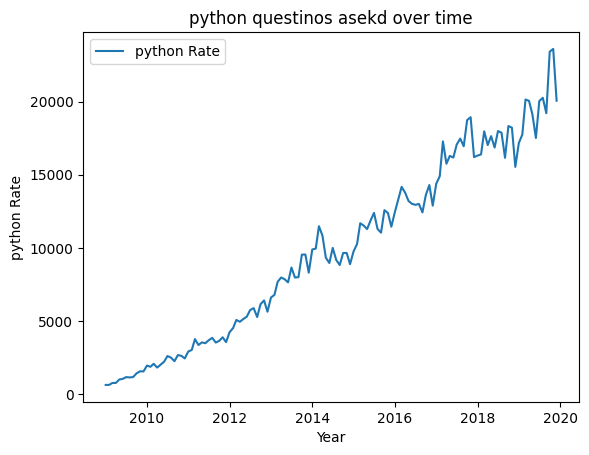

In [4]:
# visualize the time series
plt.plot(timeseries['python'], label='python Rate')
plt.xlabel('Year')
plt.ylabel('python Rate')
plt.legend()
plt.title('python questinos asekd over time')
plt.show();

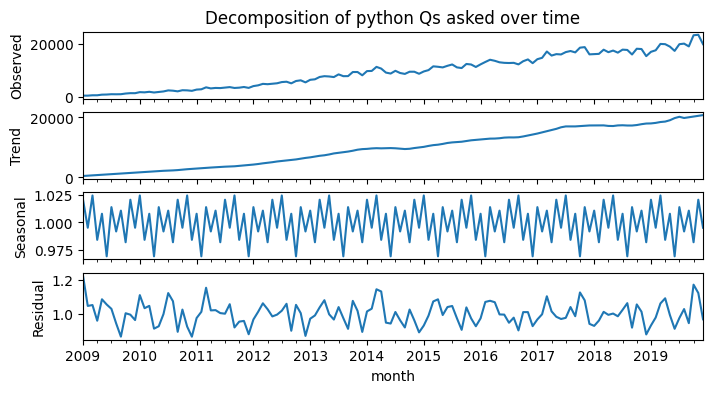

In [5]:
# Checking out the decompositions
from statsmodels.tsa.seasonal import seasonal_decompose

# setting the period makes the assumption that the seasonal trend should happen every "period" units (e.g. 10 years, or 5 days)
# can change model='multiplicative' to see if there's a change in seasonal trend
decomp1 = seasonal_decompose(timeseries['python'], period=10, model='multiplicative', extrapolate_trend='freq')
decomp2 = seasonal_decompose(timeseries['python'], period=5, model='additive', extrapolate_trend='freq')

fig, ax = plt.subplots(ncols=1, nrows=4, sharex=True, figsize=(8,4))
ax[0].set_title('Decomposition of python Qs asked over time')
decomp1.observed.plot(ax=ax[0], legend=False)
ax[0].set_ylabel('Observed')

decomp1.trend.plot(ax=ax[1], legend=False)
ax[1].set_ylabel('Trend')

decomp1.seasonal.plot(ax=ax[2], legend=False)
ax[2].set_ylabel('Seasonal')

decomp1.resid.plot(ax=ax[3], legend=False)
ax[3].set_ylabel('Residual')

plt.show();

In [6]:
for i in range(1, 11):
    timeseries[f'Lag {i}'] = timeseries['python'].shift(i)

# there will be some missing values for the early years, since we don't have (e.g.) 1870 to predict 1871
# this means (with a maximum lag of 10 to investigate) we lost years 1871-1880:
strikeout = timeseries.dropna()
strikeout.head()

,python,Lag 1,Lag 2,Lag 3,Lag 4,Lag 5,Lag 6,Lag 7,Lag 8,Lag 9,Lag 10
month,,,,,,,,,,,
2009-11-01,1562,1424.0,1169.0,1143.0,1165.0,1046.0,1003.0,768.0,766.0,633.0,631.0
2009-12-01,1552,1562.0,1424.0,1169.0,1143.0,1165.0,1046.0,1003.0,768.0,766.0,633.0
2010-01-01,1952,1552.0,1562.0,1424.0,1169.0,1143.0,1165.0,1046.0,1003.0,768.0,766.0
2010-02-01,1872,1952.0,1552.0,1562.0,1424.0,1169.0,1143.0,1165.0,1046.0,1003.0,768.0
2010-03-01,2076,1872.0,1952.0,1552.0,1562.0,1424.0,1169.0,1143.0,1165.0,1046.0,1003.0


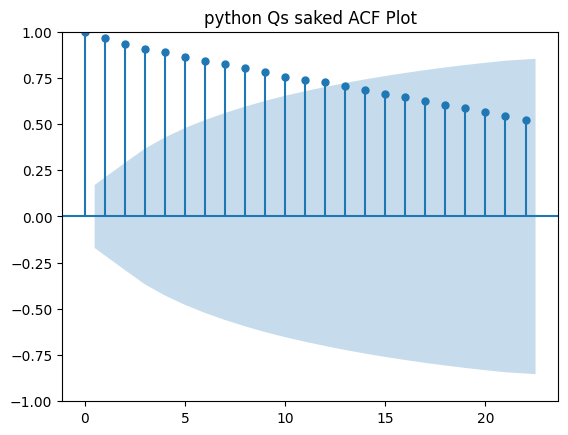

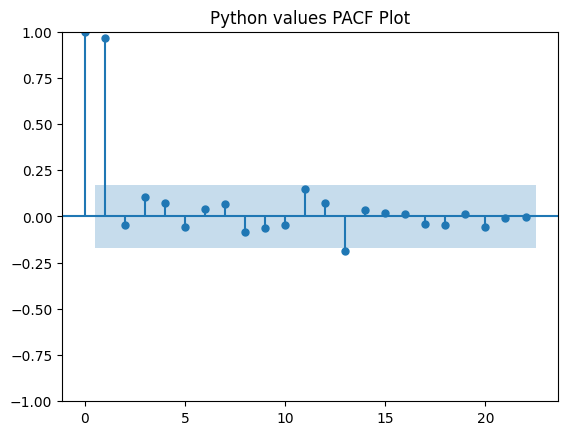

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# use the original data
series = timeseries['python']
plot_acf(series, title = 'python Qs saked ACF Plot')
plt.show();
# Looks like even up to a lag of 10 could provide significant information about the ensuing years

plot_pacf(series, title = 'Python values PACF Plot')
plt.show()

AR model should be used because after 2 lags, there a sharp cutoff in the PACF plot, while the ACF plot decreases gradually. 

In [8]:
train_size = int(.8 * len(timeseries))
train_data = timeseries[:train_size]
test_data = timeseries[train_size:]

# put the y feature (the current SO9) in arrays
y_train = np.array(train_data['python']).reshape(-1,1)
y_test = np.array(test_data['python']).reshape(-1,1)

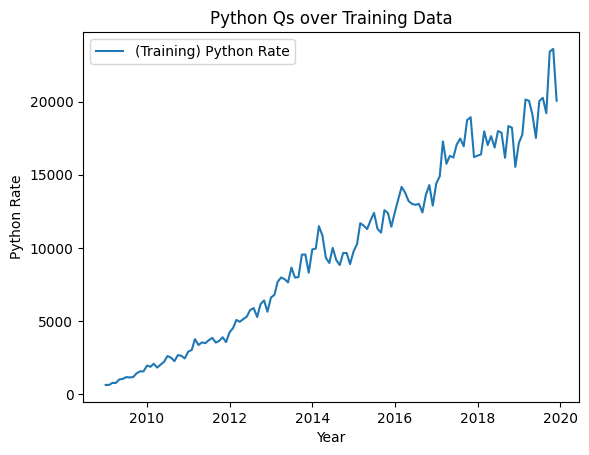

In [9]:
# visualize the time series
plt.plot(timeseries['python'], label='(Training) Python Rate')
plt.xlabel('Year')
plt.ylabel('Python Rate')
plt.legend()
plt.title('Python Qs over Training Data')
plt.show();

In [17]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import AutoReg

# lag 2 because it cuts off after lag 2 in the PACF plots
ar_model = AutoReg(y_train, lags=1, trend='n') # the default is to add an intercept (or, trend='c'), 
# using trend='n' is more in line with traditional AR(p) models, but may result in a nonstationary model
ar_results = ar_model.fit()

ar_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                      y   No. Observations:                  105
Model:                     AutoReg(1)   Log Likelihood                -827.124
Method:               Conditional MLE   S.D. of innovations            688.266
Date:                Sun, 13 Apr 2025   AIC                           1658.248
Time:                        11:26:23   BIC                           1663.536
Sample:                             1   HQIC                          1660.390
                                  105                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
y.L1           1.0142      0.008    134.248      0.000       0.999       1.029
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            0.9860           +0.0000j            0.9860            0.0000
-----------------------------------------------------------------------------
"""

In [68]:
ar_pred = ar_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)
pred_data2 = pd.DataFrame({'Year': test_data.index, 'pred Python Qs': ar_pred.flatten()})
pred_data2.set_index('Year', inplace = True)
pred_data2.head()

,pred Python Qs
Year,
2017-10-01,17189.894180
2017-11-01,17434.212161
2017-12-01,17682.002605
2018-01-01,17933.314867
2018-02-01,18188.199000


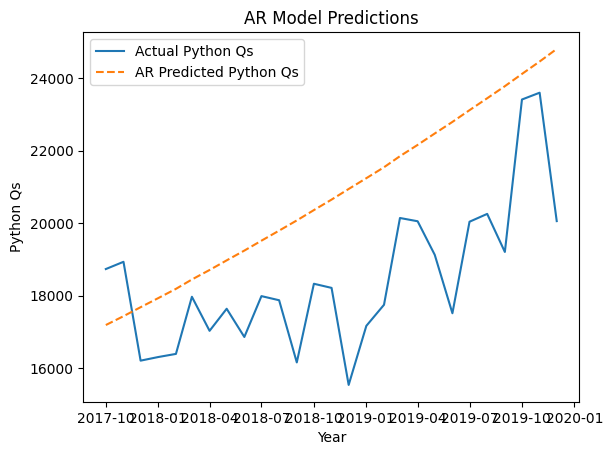

In [69]:
plt.plot(test_data['python'], label = 'Actual Python Qs')
plt.plot(pred_data2['pred Python Qs'], label = 'AR Predicted Python Qs', linestyle = '--')
plt.xlabel('Year')
plt.ylabel('Python Qs')
plt.legend()
plt.title('AR Model Predictions')
plt.show();

In [95]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

ar_pred = ar_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)
ar_pred = ar_pred.reshape(-1,1)
ar_pred = ar_pred[~np.isnan(ar_pred)]
y_test = y_test[~np.isnan(y_test)]

mae = mean_absolute_error(y_test, ar_pred)
rmse = np.sqrt(mean_squared_error(y_test, ar_pred))
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')

Mean Absolute Error: 2538.68
Root Mean Squared Error: 2891.82


Results are pretty bad, so try ARIMA model

In [61]:
from statsmodels.tsa.arima.model import ARIMA
arma_model = ARIMA(y_train, order=(5, 1, 10))
arma_results = arma_model.fit()

#summary of the model
arma_results.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  105
Model:                ARIMA(5, 1, 10)   Log Likelihood                -809.476
Date:                Sun, 13 Apr 2025   AIC                           1650.952
Time:                        12:12:12   BIC                           1693.263
Sample:                             0   HQIC                          1668.094
                                - 105                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0151      0.225     -0.067      0.946      -0.456       0.426
ar.L2         -0.8020      0.258     -3.105      0.002      -1.308      -0.296
ar.L3          0.7969      0.227      3.504      0.000       0.351       1.243
ar.L4          0.1571      0.254      0.618      0.536      -0.341       0.655
ar.L5          0.8110      0.194      4.172      0.000       0.430       1.192
ma.L1         -0.1888      0.329     -0.573      0.566      -0.834       0.457
ma.L2          0.9346      0.384      2.431      0.015       0.181       1.688
ma.L3         -1.2028      0.457     -2.630      0.009      -2.099      -0.306
ma.L4          0.2258      0.521      0.434      0.665      -0.795       1.246
ma.L5         -1.3021      0.477     -2.732      0.006      -2.236      -0.368
ma.L6          0.6293      0.490      1.285      0.199      -0.331       1.589
ma.L7         -0.3442      0.514     -0.670      0.503      -1.351       0.663
ma.L8          0.5173      0.448      1.155      0.248      -0.361       1.396
ma.L9         -0.0554      0.327     -0.169      0.866      -0.697       0.586
ma.L10        -0.0246      0.292     -0.084      0.933      -0.597       0.548
sigma2      5.288e+05   1.45e+05      3.644      0.000    2.44e+05    8.13e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.20   Jarque-Bera (JB):                 6.73
Prob(Q):                              0.65   Prob(JB):                         0.03
Heteroskedasticity (H):               7.80   Skew:                             0.13
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.22
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [85]:
arma_pred = arma_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)
pred_data = pd.DataFrame({'Year': test_data.index, 'python': arma_pred.flatten()})
pred_data.set_index('Year', inplace = True)
pred_data.head()

,python
Year,
2017-10-01,17859.069369
2017-11-01,17983.902191
2017-12-01,17743.733568
2018-01-01,17419.495706
2018-02-01,18429.114758


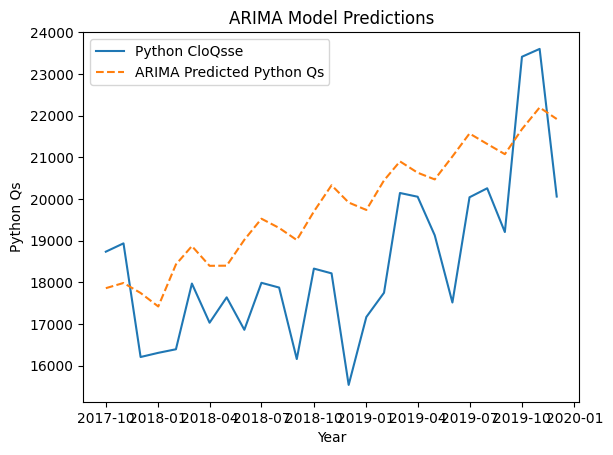

In [87]:
plt.plot(test_data['python'], label = 'Python CloQsse')
plt.plot(pred_data['python'], label = 'ARIMA Predicted Python Qs', linestyle = '--')
plt.xlabel('Year')
plt.ylabel('Python Qs')
plt.legend()
plt.title('ARIMA Model Predictions')
plt.show();

In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


print(y_test.shape)
print(pred_data.shape)
mae = mean_absolute_error(y_test, pred_data)
rmse = np.sqrt(mean_squared_error(y_test, pred_data))
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')

(27,)
(27, 1)
Mean Absolute Error: 1715.04
Root Mean Squared Error: 1921.97


In [58]:
arima_model = ARIMA(y_train, order=(10,5,5))
results = arima_model.fit()
results.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  105
Model:                ARIMA(10, 5, 5)   Log Likelihood                -802.219
Date:                Sun, 13 Apr 2025   AIC                           1636.439
Time:                        12:11:32   BIC                           1678.121
Sample:                             0   HQIC                          1653.308
                                - 105                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -2.3521      0.701     -3.354      0.001      -3.726      -0.978
ar.L2         -3.6202      1.734     -2.088      0.037      -7.019      -0.222
ar.L3         -4.4611      2.855     -1.563      0.118     -10.056       1.134
ar.L4         -4.4847      3.650     -1.229      0.219     -11.640       2.670
ar.L5         -3.8397      3.945     -0.973      0.330     -11.573       3.893
ar.L6         -2.7845      3.749     -0.743      0.458     -10.133       4.564
ar.L7         -1.6293      3.120     -0.522      0.602      -7.745       4.486
ar.L8         -0.6197      2.254     -0.275      0.783      -5.038       3.799
ar.L9          0.0801      1.294      0.062      0.951      -2.456       2.617
ar.L10         0.2859      0.469      0.609      0.542      -0.634       1.205
ma.L1         -1.2518      0.744     -1.682      0.093      -2.711       0.207
ma.L2          0.2809      0.884      0.318      0.751      -1.452       2.014
ma.L3         -0.2247      0.552     -0.407      0.684      -1.307       0.858
ma.L4         -0.1078      0.573     -0.188      0.851      -1.230       1.015
ma.L5          0.3725      0.370      1.007      0.314      -0.352       1.098
sigma2      6.767e+05   1.97e+05      3.431      0.001     2.9e+05    1.06e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 8.91
Prob(Q):                              0.83   Prob(JB):                         0.01
Heteroskedasticity (H):               9.83   Skew:                            -0.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [59]:
arima_pred = results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)
pred_data = pd.DataFrame({'Year': test_data.index, 'python': arima_pred.flatten()})
pred_data.set_index('Year', inplace = True)
pred_data.head()

,python
Year,
2017-10-01,17767.699702
2017-11-01,17900.128995
2017-12-01,16538.423561
2018-01-01,16821.204000
2018-02-01,16630.532481


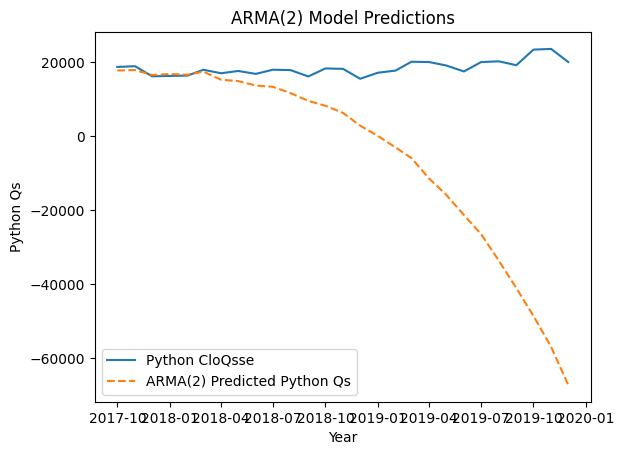

In [60]:
plt.plot(test_data['python'], label = 'Python CloQsse')
plt.plot(pred_data['python'], label = 'ARMA(2) Predicted Python Qs', linestyle = '--')
plt.xlabel('Year')
plt.ylabel('Python Qs')
plt.legend()
plt.title('ARMA(2) Model Predictions')
plt.show();